In [46]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [27]:
# Load ARFF file
data, meta = arff.loadarff("/content/EEG Eye State.arff")

# Convert to DataFrame
df = pd.DataFrame(data)

# Decode byte strings (important)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode("utf-8")

# Save as CSV
df.to_csv("EEG_Eye_State.csv", index=False)

print("ARFF file successfully converted to CSV")

ARFF file successfully converted to CSV


In [28]:
# upload the csv file
df = pd.read_csv("EEG_Eye_State.csv")
df

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14975,4281.03,3990.26,4245.64,4116.92,4333.85,4614.36,4074.87,4625.64,4203.08,4221.54,4171.28,4269.23,4593.33,4340.51,1
14976,4276.92,3991.79,4245.13,4110.77,4332.82,4615.38,4073.33,4621.54,4194.36,4217.44,4162.56,4259.49,4590.26,4333.33,1
14977,4277.44,3990.77,4246.67,4113.85,4333.33,4615.38,4072.82,4623.59,4193.33,4212.82,4160.51,4257.95,4591.79,4339.49,1
14978,4284.62,3991.79,4251.28,4122.05,4334.36,4616.41,4080.51,4628.72,4200.00,4220.00,4165.64,4267.18,4596.41,4350.77,1


In [29]:
# Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


In [30]:
# Count of each class
df['eyeDetection'].value_counts()

,count
eyeDetection,
0,8257
1,6723


In [31]:
# Percentage distribution
df['eyeDetection'].value_counts(normalize=True) * 100

,proportion
eyeDetection,
0,55.12016
1,44.87984


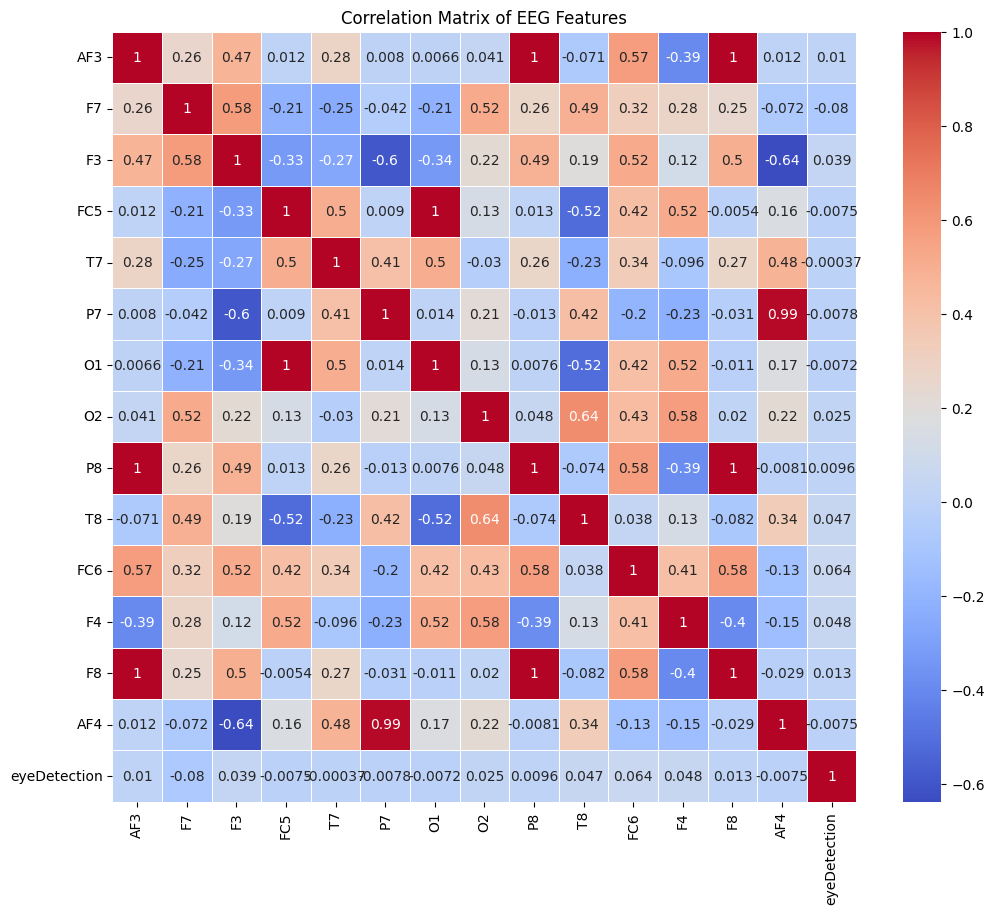

In [49]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5, annot=True)
plt.title("Correlation Matrix of EEG Features")
plt.show()

In [33]:
# Correlation matrix
corr_matrix = df.corr()

# Display correlation of features with target
corr_matrix['eyeDetection'].sort_values(ascending=False)

,eyeDetection
eyeDetection,1.000000
FC6,0.064294
F4,0.047965
T8,0.047218
F3,0.038902
O2,0.025100
F8,0.013120
AF3,0.010458
P8,0.009576
T7,-0.000369


In [34]:
# Separate features and target
X = df.drop("eyeDetection", axis=1)
Y = df["eyeDetection"]

print(X.shape, Y.shape)


(14980, 14) (14980,)


In [35]:
# Split dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42 )


In [36]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [37]:
# Initialize Sequential model
# Sequential allows us to stack layers linearly
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation="sigmoid"))


In [38]:
# Compile the neural network model
# This step configures the model for training
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [39]:
# Train the neural network model
# This step allows the model to learn patterns from EEG signal data
history = model.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=50,
    validation_split=0.2,
    verbose=1
)


Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5413 - loss: 0.6930 - val_accuracy: 0.5857 - val_loss: 0.6510
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5906 - loss: 0.6581 - val_accuracy: 0.6049 - val_loss: 0.6399
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5956 - loss: 0.6540 - val_accuracy: 0.6191 - val_loss: 0.6311
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6050 - loss: 0.6434 - val_accuracy: 0.6366 - val_loss: 0.6270
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6193 - loss: 0.6371 - val_accuracy: 0.6475 - val_loss: 0.6167
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6208 - loss: 0.6350 - val_accuracy: 0.6587 - val_loss: 0.6108
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6400 - loss: 0.6224 - val_accuracy: 0.6612 - val_loss: 0.6022
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6381 - loss: 0.6244 - val_accu

In [40]:
# Evaluate model performance on test data
loss, accuracy = model.evaluate(X_test, Y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8087 - loss: 0.3994
Test Loss: 0.4040347635746002
Test Accuracy: 0.807076096534729


In [42]:
# Convert probabilities to binary predictions
Y_pred = (model.predict(X_test) > 0.5).astype(int)


# Performance metrics
print("Accuracy:", accuracy_score(Y_test, Y_pred))

print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

print("Classification Report:\n", classification_report(Y_test, Y_pred))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.8070761014686249
Confusion Matrix:
 [[1358  228]
 [ 350 1060]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.82      1586
           1       0.82      0.75      0.79      1410

    accuracy                           0.81      2996
   macro avg       0.81      0.80      0.81      2996
weighted avg       0.81      0.81      0.81      2996

